Import Panda to read the file

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

import matplotlib.pyplot as plt
import seaborn as sns
from calendar import month_name
from windrose import WindroseAxes

### Summary Statistics & Missing-Value Report

In [2]:
#read benin file
df = pd.read_csv('../data/benin-malanville.csv')
#take a look on the top sample data
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [33]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.0,241.958821,0.0,0.0,1.8,483.4,1413.0,330.101787
DNI,525600.0,167.441866,0.0,0.0,0.0,314.2,952.3,261.547532
DHI,525600.0,116.993033,0.0,0.0,1.6,216.3,759.2,157.463619
ModA,525600.0,236.589496,0.0,0.0,4.5,463.7,1342.3,326.894859
ModB,525600.0,228.883576,0.0,0.0,4.3,447.9,1342.3,316.536515
Tamb,525600.0,28.179683,11.0,24.2,28.0,32.3,43.8,5.924297
RH,525600.0,54.487969,2.1,28.8,55.1,80.1,100.0,28.073069
WS,525600.0,2.121113,0.0,1.0,1.9,3.1,19.5,1.603466
WSgust,525600.0,2.809195,0.0,1.3,2.6,4.1,26.6,2.02912


In [34]:
df.dtypes

Timestamp        datetime64[ns]
GHI                     float64
DNI                     float64
DHI                     float64
ModA                    float64
ModB                    float64
Tamb                    float64
RH                      float64
WS                      float64
WSgust                  float64
WSstdev                 float64
WD                      float64
WDstdev                 float64
BP                        int64
Cleaning                  int64
Precipitation           float64
TModA                   float64
TModB                   float64
dtype: object

In [6]:
# Convert 'Timestamp' column to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
# df.set_index('Timestamp', inplace=True)

In [35]:
# #check missing data value for each column 
missing_report = df.isna().sum().to_frame(name='Missing Count')
missing_report['Missing %'] = (df.isna().mean() * 100).round(2)
print(missing_report)


               Missing Count  Missing %
Timestamp                  0        0.0
GHI                        0        0.0
DNI                        0        0.0
DHI                        0        0.0
ModA                       0        0.0
ModB                       0        0.0
Tamb                       0        0.0
RH                         0        0.0
WS                         0        0.0
WSgust                     0        0.0
WSstdev                    0        0.0
WD                         0        0.0
WDstdev                    0        0.0
BP                         0        0.0
Cleaning                   0        0.0
Precipitation              0        0.0
TModA                      0        0.0
TModB                      0        0.0


In [12]:

high_missing = missing_report[missing_report['Missing %'] > 5]
# print the columns with more than 5% missing values
print(high_missing)


          Missing Count  Missing %
Comments         525600      100.0


In [13]:
# eliminate column with above 5% of null data value
df = df.drop(columns=['Comments'])

In [14]:
print(df.columns)

Index(['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS',
       'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation',
       'TModA', 'TModB'],
      dtype='object')


### Outlier Detection & Basic Cleaning

In [15]:

numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)


['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB']


In [16]:
Target_Column = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
print(Target_Column)

['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']


In [17]:
df[Target_Column].describe()

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,240.559452,167.187516,115.358961,236.589496,228.883576,2.121113,2.809195
std,331.131327,261.710501,158.691074,326.894859,316.536515,1.603466,2.029120
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,0.000000,0.000000
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,1.000000,1.300000
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,1.900000,2.600000
75%,483.400000,314.200000,216.300000,463.700000,447.900000,3.100000,4.100000
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,19.500000,26.600000


In [18]:
df[["GHI", "DNI" , "DHI"]] = df[["GHI", "DNI" , "DHI"]].clip(lower=0)
print("\nAfter fixing:")
print(df[["GHI", "DNI" , "DHI"]].describe())


After fixing:
                 GHI            DNI            DHI
count  525600.000000  525600.000000  525600.000000
mean      241.958821     167.441866     116.993033
std       330.101787     261.547532     157.463619
min         0.000000       0.000000       0.000000
25%         0.000000       0.000000       0.000000
50%         1.800000       0.000000       1.600000
75%       483.400000     314.200000     216.300000
max      1413.000000     952.300000     759.200000


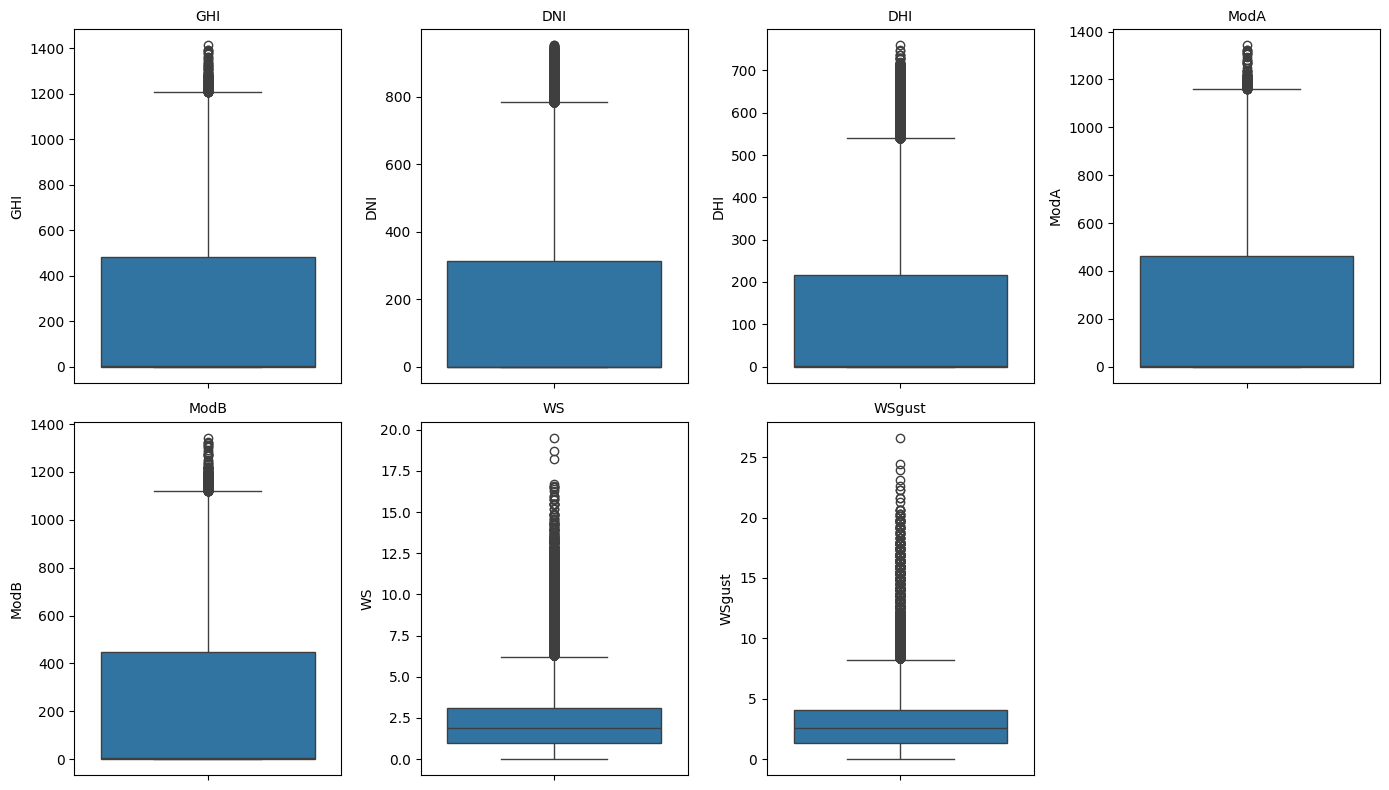

In [32]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(Target_Column):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.show()

In [31]:
# zscore to remove the outliers 

# Compute Z-scores
zscores = np.abs(zscore(df[Target_Column]))

# Mask for rows with all Z-scores <= 3 (i.e., no outliers)
no_outliers_mask = (zscores <= 3).all(axis=1)

# Apply the mask to get cleaned data
df_clean = df[no_outliers_mask]

# Compare before and after
print("Original rows:", df.shape[0])
print("Rows after outlier removal:", df_clean.shape[0])

Original rows: 525600
Rows after outlier removal: 517707


In [30]:
# Export cleaned data to CSV
df_clean.to_csv('../data/benin_clean.csv', index=False)
print(f"Cleaned data saved")

Cleaned data saved


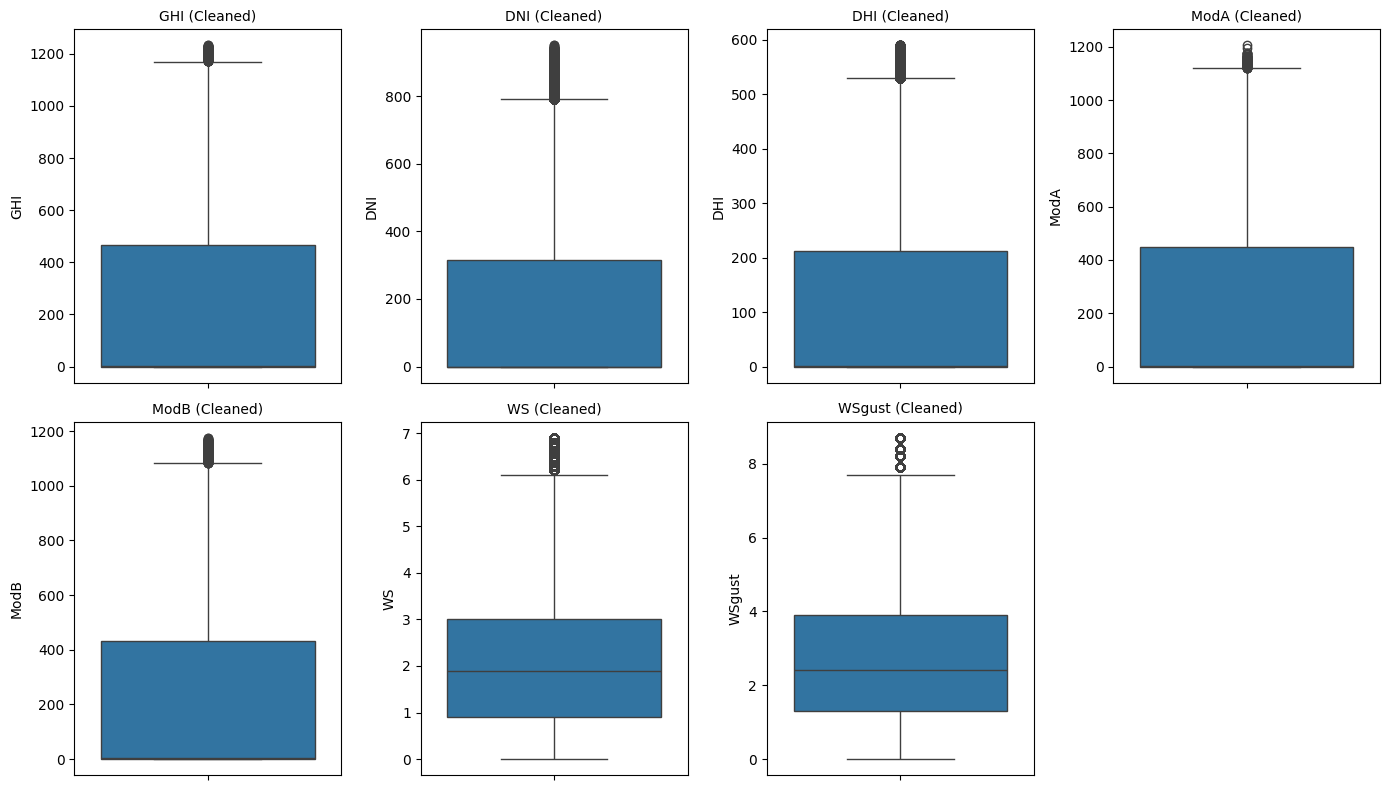

In [22]:
#box plot after cleanup 
plt.figure(figsize=(14, 8))
for i, col in enumerate(Target_Column):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(y=df_clean[col])
    plt.title(f"{col} (Cleaned)", fontsize=10)
plt.tight_layout()
plt.show()


### Time Series Analysis


In [37]:
# Sort by time
df = df_clean.sort_values('Timestamp')
# Set as index (makes time series plotting easier)
df.set_index('Timestamp', inplace=True)


<Figure size 1600x800 with 0 Axes>

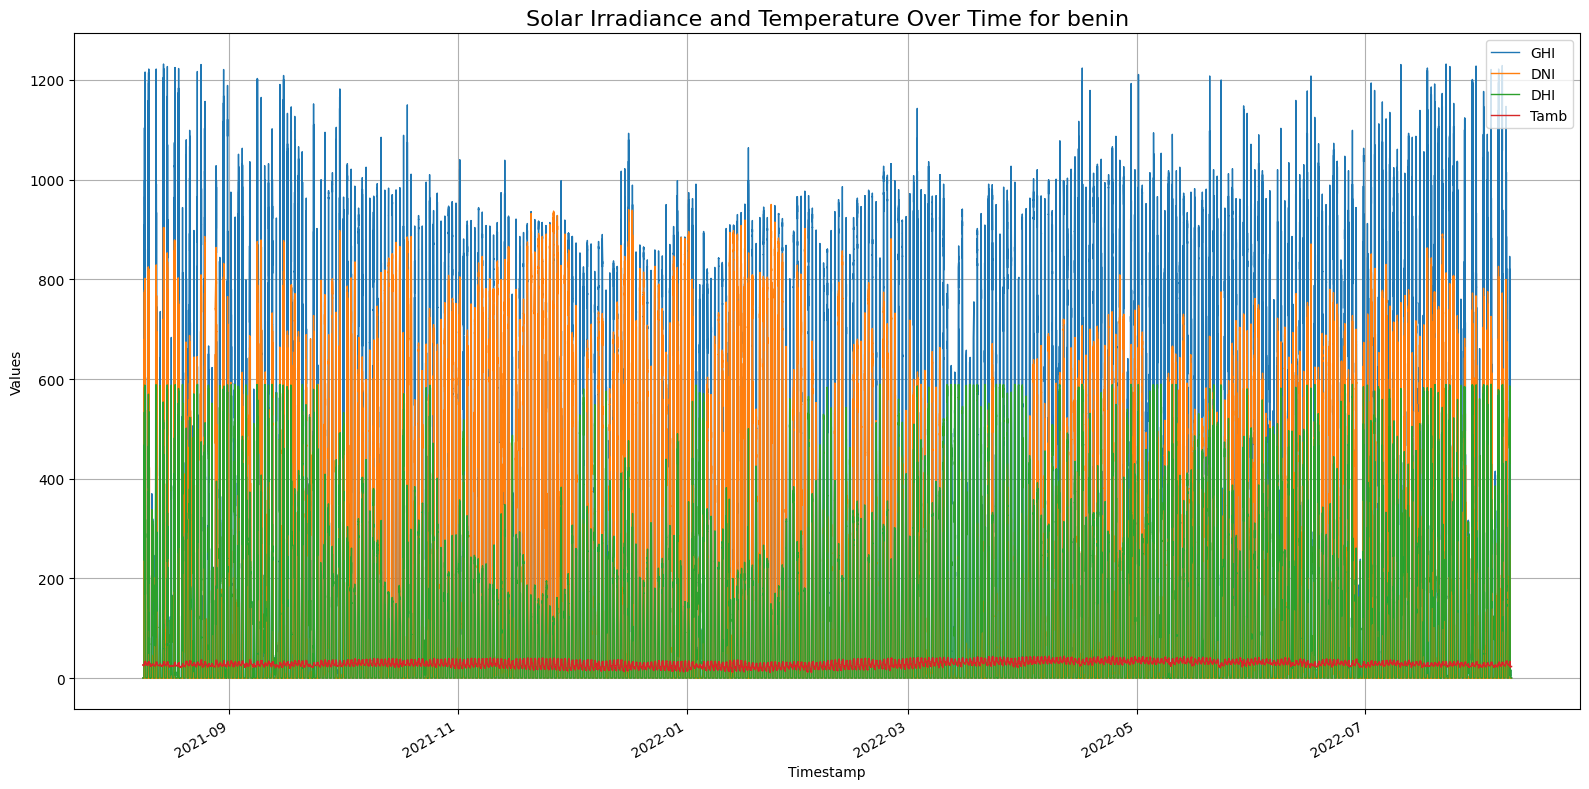

In [38]:
# Create a multi-line plot
plt.figure(figsize=(16, 8))

# Plot each variable
df[['GHI', 'DNI', 'DHI', 'Tamb']].plot(figsize=(16, 8), linewidth=1)

plt.title("Solar Irradiance and Temperature Over Time for benin", fontsize=16)
plt.ylabel("Values")
plt.xlabel("Timestamp")
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

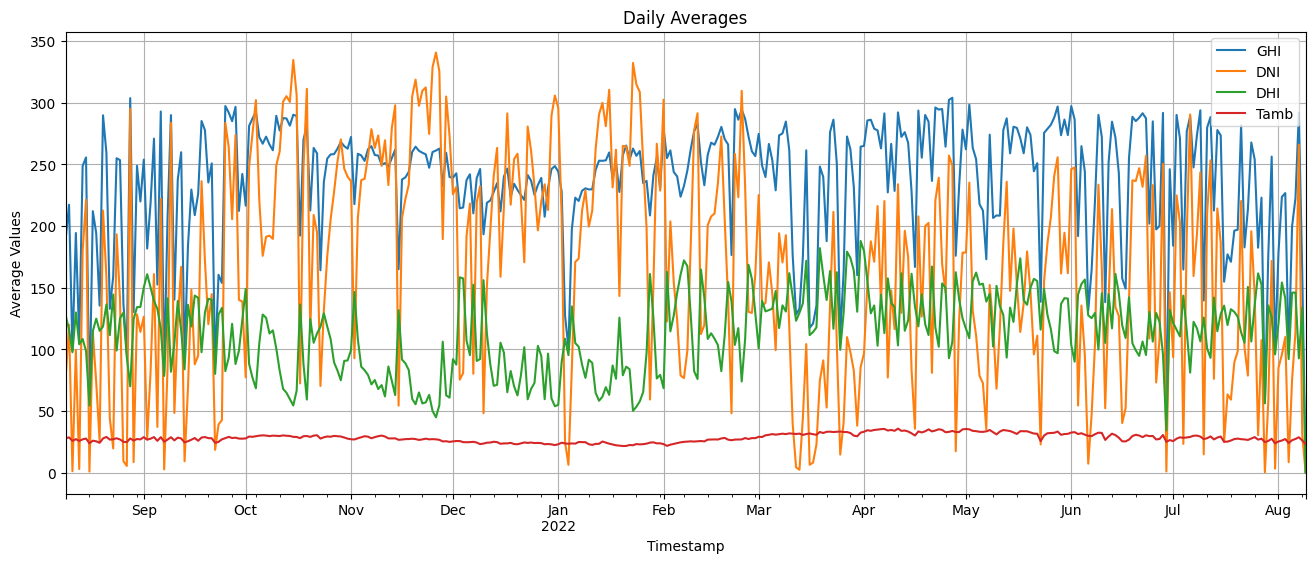

In [39]:
# Daily average plot
df_daily = df[['GHI', 'DNI', 'DHI', 'Tamb']].resample('D').mean()

df_daily.plot(figsize=(16, 6), title='Daily Averages')
plt.ylabel('Average Values')
plt.grid(True)
plt.show()

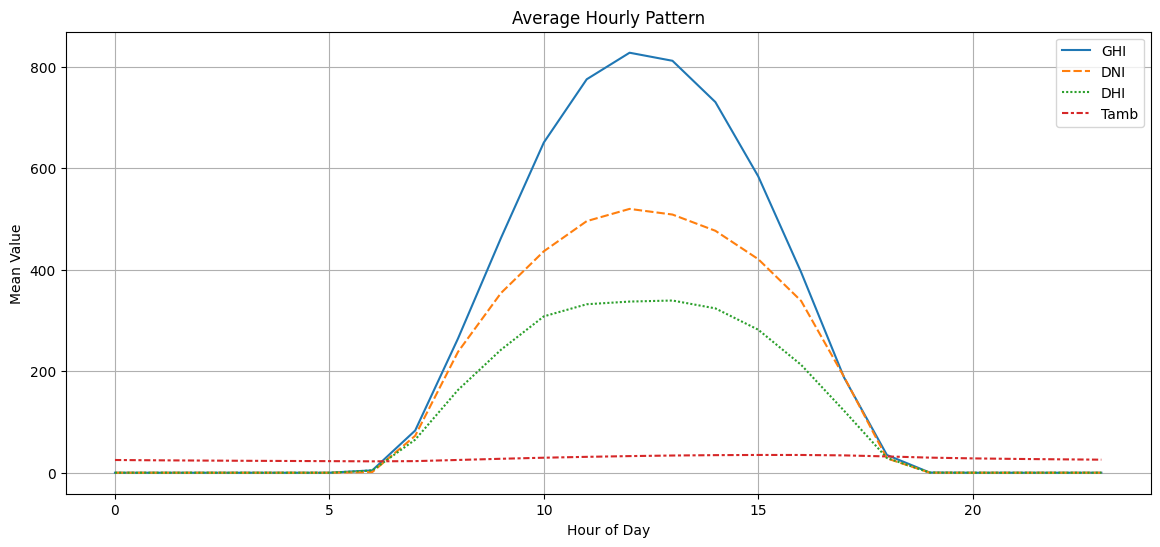

In [40]:
# Add hour column to see how things change throughout the day
df['hour'] = df.index.hour

# Plot average values per hour
plt.figure(figsize=(14, 6))
sns.lineplot(data=df.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean())
plt.title('Average Hourly Pattern')
plt.ylabel('Mean Value')
plt.xlabel('Hour of Day')
plt.grid(True)
plt.show()

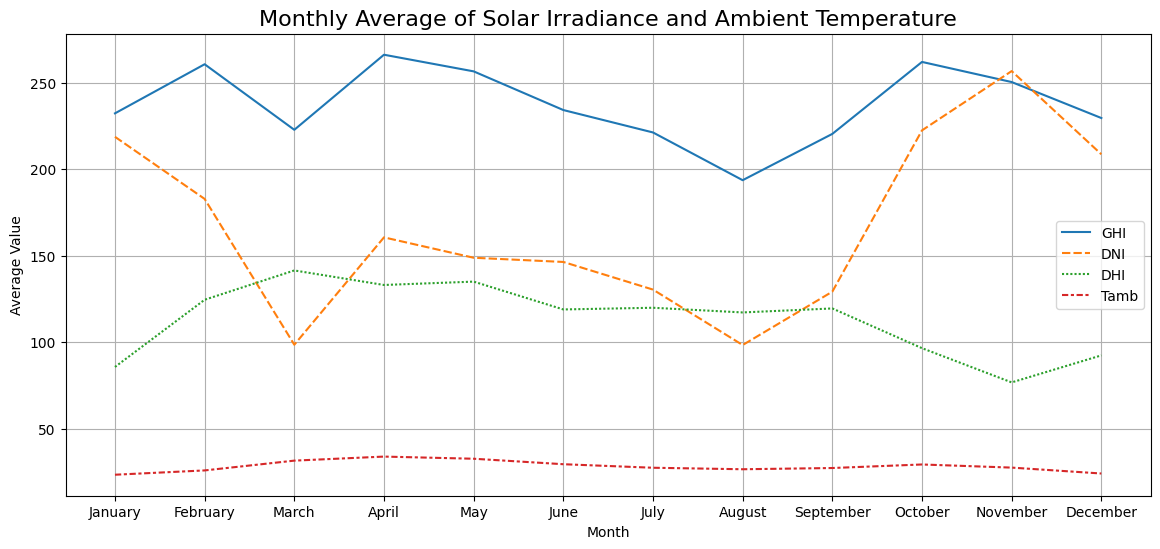

In [41]:
# Extract month names from the DatetimeIndex
df['Month'] = df.index.month_name()

# Group by month name and compute the mean for each variable
monthly_avg = df.groupby('Month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

# Ensure months are in calendar order
month_order = list(month_name)[1:]  # Skips the empty string at index 0
monthly_avg = monthly_avg.reindex(month_order)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_avg)
plt.title("Monthly Average of Solar Irradiance and Ambient Temperature", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()


### Cleaning Impact


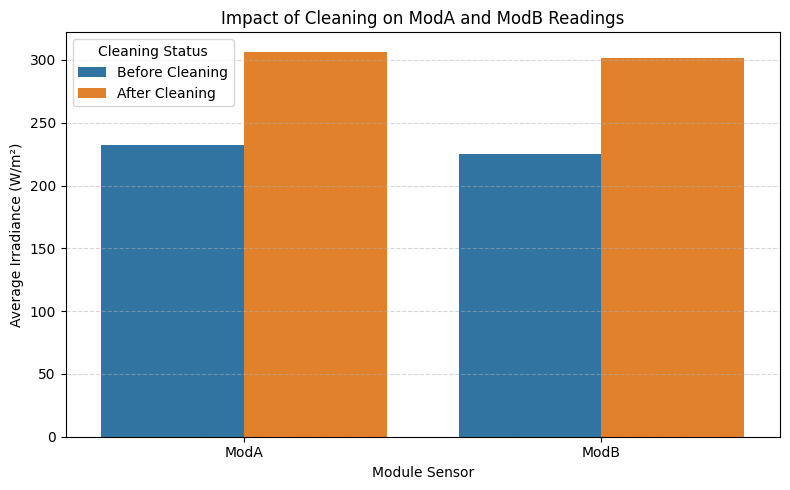

In [45]:
# Group by Cleaning status (0 = no cleaning, 1 = cleaned)
cleaning_impact = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

# Reset index for plotting
cleaning_impact = cleaning_impact.reset_index()
cleaning_impact['Cleaning'] = cleaning_impact['Cleaning'].map({0: 'Before Cleaning', 1: 'After Cleaning'})

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(data=cleaning_impact.melt(id_vars='Cleaning', value_vars=['ModA', 'ModB']),
            x='variable', y='value', hue='Cleaning')

plt.title('Impact of Cleaning on ModA and ModB Readings')
plt.ylabel('Average Irradiance (W/m²)')
plt.xlabel('Module Sensor')
plt.legend(title='Cleaning Status')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Correlation & Relationship Analysis


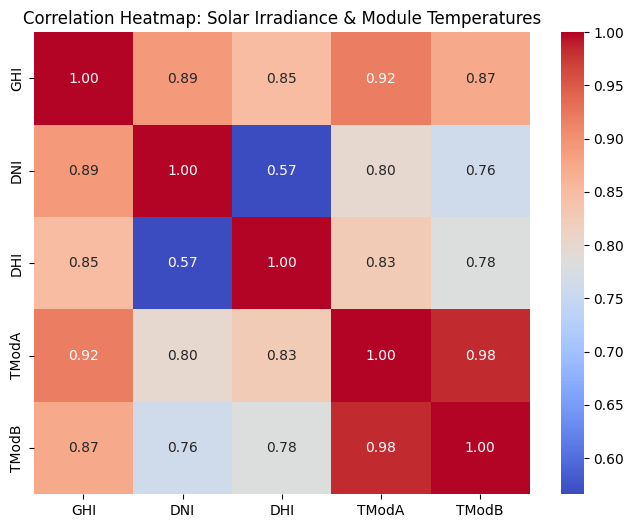

In [46]:
# Select columns for correlation heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr_matrix = df[corr_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Solar Irradiance & Module Temperatures")
plt.show()

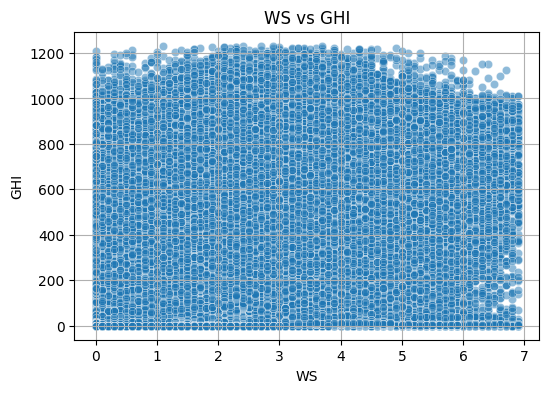

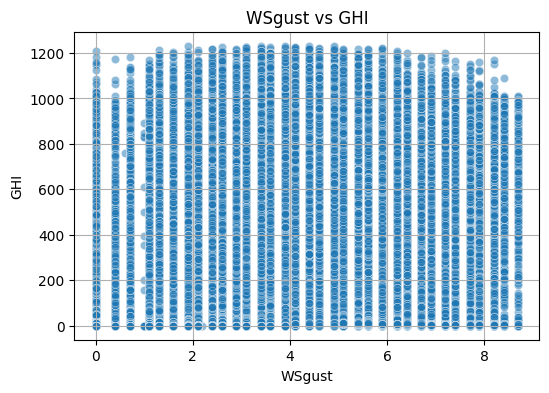

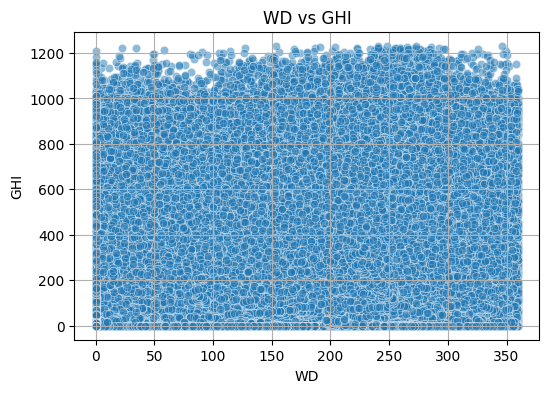

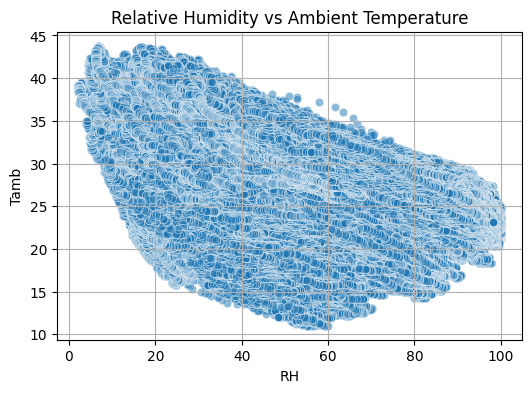

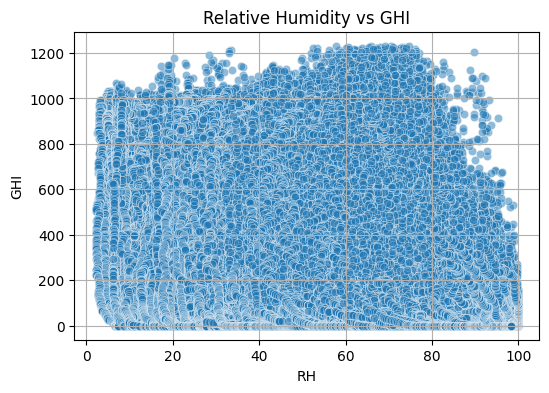

In [58]:
# WS, WSgust, WD vs. GHI
scatter_vars = ['WS', 'WSgust', 'WD']
for var in scatter_vars:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=var, y='GHI', alpha=0.5)
    plt.title(f'{var} vs GHI')
    plt.grid(True)
    plt.show()

# RH vs Tamb
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title('Relative Humidity vs Ambient Temperature')
plt.grid(True)
plt.show()

# RH vs GHI
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5)
plt.title('Relative Humidity vs GHI')
plt.grid(True)
plt.show()

### Wind & Distribution Analysis

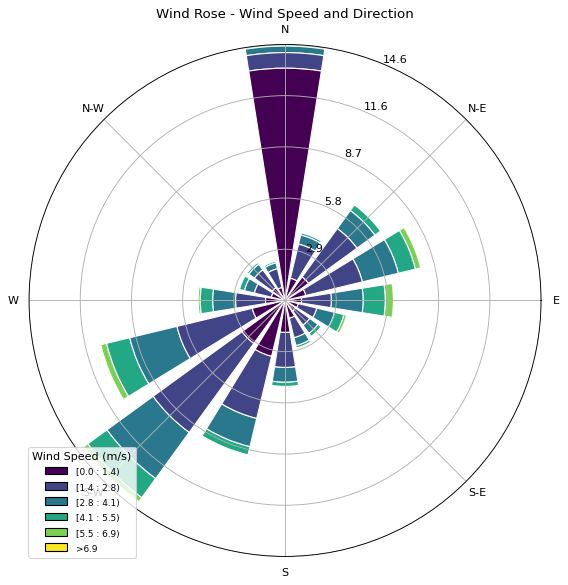

In [50]:
# Drop NA values for WS and WD
wind_data = df[['WS', 'WD']].dropna()

# Create wind rose
ax = WindroseAxes.from_ax()
ax.bar(wind_data['WD'], wind_data['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title="Wind Speed (m/s)")
plt.title("Wind Rose - Wind Speed and Direction")
plt.show()

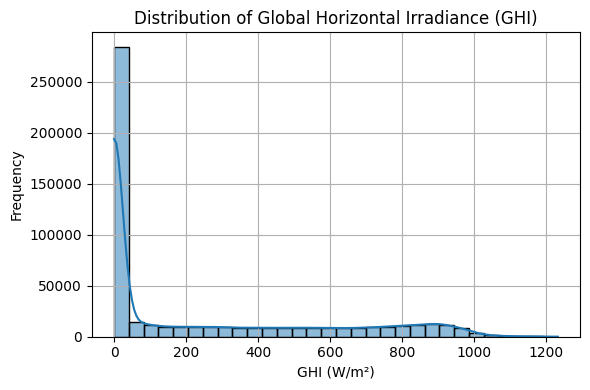

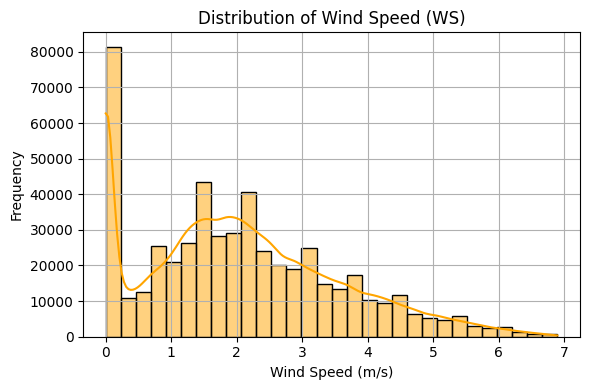

In [53]:
# Histogram for GHI
plt.figure(figsize=(6, 4))
sns.histplot(df['GHI'].dropna(), bins=30, kde=True)
plt.title("Distribution of Global Horizontal Irradiance (GHI)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Histogram for Wind Speed (WS)
plt.figure(figsize=(6, 4))
sns.histplot(df['WS'].dropna(), bins=30, kde=True, color='orange')
plt.title("Distribution of Wind Speed (WS)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


### Temperature Analysis


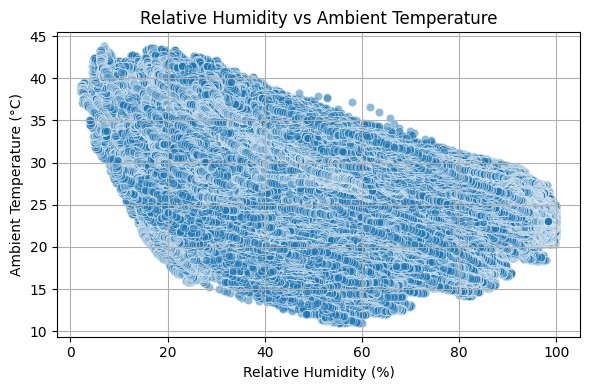

In [54]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='Tamb', alpha=0.5)
plt.title("Relative Humidity vs Ambient Temperature")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

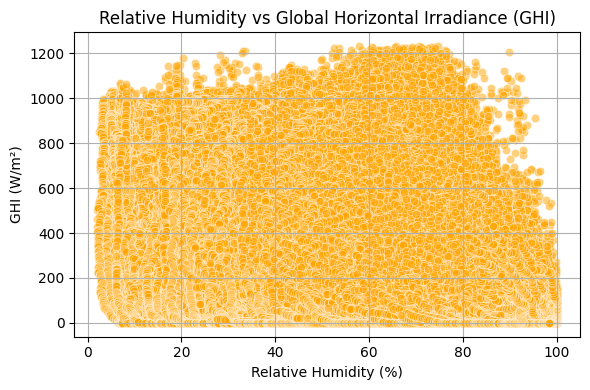

In [55]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RH', y='GHI', alpha=0.5, color='orange')
plt.title("Relative Humidity vs Global Horizontal Irradiance (GHI)")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("GHI (W/m²)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Bubble Chart


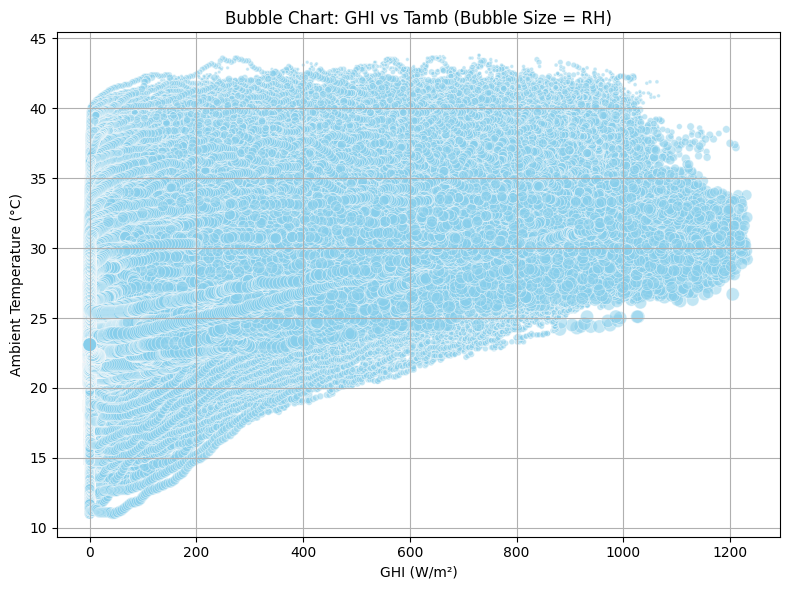

In [57]:
# Drop rows with missing values in relevant columns
bubble_df = df[['GHI', 'Tamb', 'RH']].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(
    bubble_df['GHI'],        # X-axis
    bubble_df['Tamb'],       # Y-axis
    s=bubble_df['RH'],       # Bubble size
    alpha=0.5,
    c='skyblue',
    edgecolors='w',
    linewidths=0.5
)

plt.title("Bubble Chart: GHI vs Tamb (Bubble Size = RH)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()